In [1]:
# imports

import os
import logging
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import re
from sentence_transformers import SentenceTransformer
import chromadb
from sklearn.manifold import TSNE
import plotly.graph_objects as go
from litellm import completion
from tqdm import tqdm
from agents.evaluator import evaluate
from agents.items import Item

C:\Users\Rohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# environment

load_dotenv(override=True)
DB = "products_vectorstore"

In [3]:
# Log in to HuggingFace
# If you don't have a HuggingFace account, you can set one up for free at www.huggingface.co
# And then add the HF_TOKEN to your .env file as explained in the project README

hf_token = os.environ['HF_TOKEN']
login(token=hf_token, add_to_git_credential=False)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
LITE_MODE = False

In [11]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [6]:
# Now we load the dataset into ChromaDB
client = chromadb.PersistentClient(path=DB)

### Introducing the SentenceTransformer Encoding LLM

The all-MiniLM is a very useful model from HuggingFace that maps sentences & paragraphs to 384 dimensional vectors and is ideal for tasks like semantic search.

https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

It can run pretty quickly locally.

As an alternative, OpenAI provides a closed-source Embeddings model. Benefits compared to OpenAI embeddings:
1. It's free and fast!
3. We can run it locally, so the data never leaves our box - might be useful if you're building a personal RAG

In [12]:
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights: 100%|██████████████████████████████████████| 103/103 [00:00<00:00, 416.79it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Pass in a list of texts, get back a numpy array of vectors

vector = encoder.encode(["A proficient AI engineer who has almost reached the finale of AI Engineering Core Track!"])[0]
print(vector.shape)
vector

(384,)


array([-5.68234101e-02, -6.70465454e-02,  4.41129692e-02,  5.98603534e-03,
       -2.28949264e-02, -2.95300409e-02,  5.56369908e-02,  3.42665575e-02,
       -1.08529374e-01, -3.81691083e-02, -7.43872598e-02, -1.03664257e-01,
        1.69148073e-02,  1.33924722e-03, -6.86191395e-02,  8.99353921e-02,
       -1.45186391e-02, -2.43884884e-02,  4.21853038e-03, -9.62992385e-02,
       -2.51799338e-02,  4.60676327e-02,  4.95346822e-03, -3.88679579e-02,
        1.07717933e-03,  6.82337508e-02, -1.13859670e-02, -5.83416633e-02,
       -1.03801303e-02, -1.74953043e-02, -1.86478589e-02,  4.07058652e-03,
        1.59438066e-02,  6.49722442e-02,  3.71175818e-02,  2.78225169e-02,
       -4.41945195e-02, -2.34372765e-02,  9.71035361e-02, -5.06139062e-02,
       -1.93864517e-02, -3.83471437e-02,  4.76066805e-02, -3.36106345e-02,
        5.08286878e-02,  3.57935131e-02,  2.91812420e-03, -1.06529154e-01,
        4.07211818e-02, -5.85452130e-04, -1.05607502e-01, -1.03584349e-01,
        3.71124111e-02, -

In [9]:
%%time
# Check if the collection exists; if not, create it

collection_name = "products"
existing_collection_names = [collection.name for collection in client.list_collections()]
# train = train[:100_000]
if collection_name not in existing_collection_names:
    collection = client.create_collection(collection_name)
    for i in tqdm(range(0, len(train), 1000)):
        documents = [item.summary for item in train[i: i+1000]]
        vectors = encoder.encode(documents).astype(float).tolist()
        metadatas = [{"category": item.category, "price": item.price} for item in train[i: i+1000]]
        ids = [f"doc_{j}" for j in range(i, i+1000)]
        ids = ids[:len(documents)]
        collection.add(ids=ids, documents=documents, embeddings=vectors, metadatas=metadatas)

collection = client.get_or_create_collection(collection_name)

 35%|████████████████████████████████▌                                                            | 280/800 [1:25:36<2:38:59, 18.35s/it]


KeyboardInterrupt: 

In [8]:
collection_name = "products"
collection = client.get_or_create_collection(collection_name)

In [9]:
# It is very fun turning this up to 800_000 and seeing the full dataset visualized,
# but it almost crashes my box every time so do that at your own risk!! 10_000 is safe!

MAXIMUM_DATAPOINTS = 5_000

In [11]:
CATEGORIES = ['Appliances', 'Automotive', 'Cell_Phones_and_Accessories', 'Electronics','Musical_Instruments', 'Office_Products', 'Tools_and_Home_Improvement', 'Toys_and_Games']
COLORS = ['cyan', 'blue', 'brown', 'orange', 'yellow', 'green' , 'purple', 'red']

In [12]:
# Prework
result = collection.get(include=['embeddings', 'documents', 'metadatas'], limit=MAXIMUM_DATAPOINTS)
vectors = np.array(result['embeddings'])
documents = result['documents']
categories = [metadata['category'] for metadata in result['metadatas']]
colors = [COLORS[CATEGORIES.index(c)] for c in categories]

In [13]:
# Let's try a 2D chart
# TSNE stands for t-distributed Stochastic Neighbor Embedding - it's a common technique for reducing dimensionality of data

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

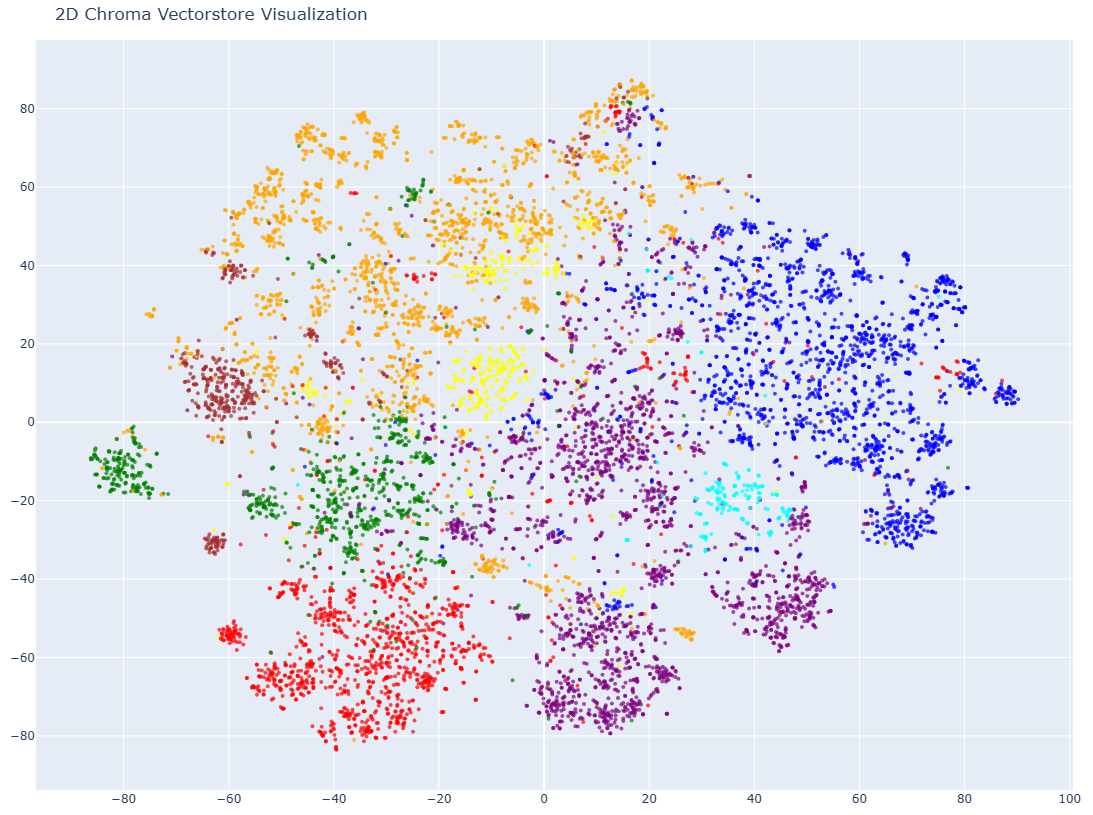

In [14]:
# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=4, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vectorstore Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [15]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

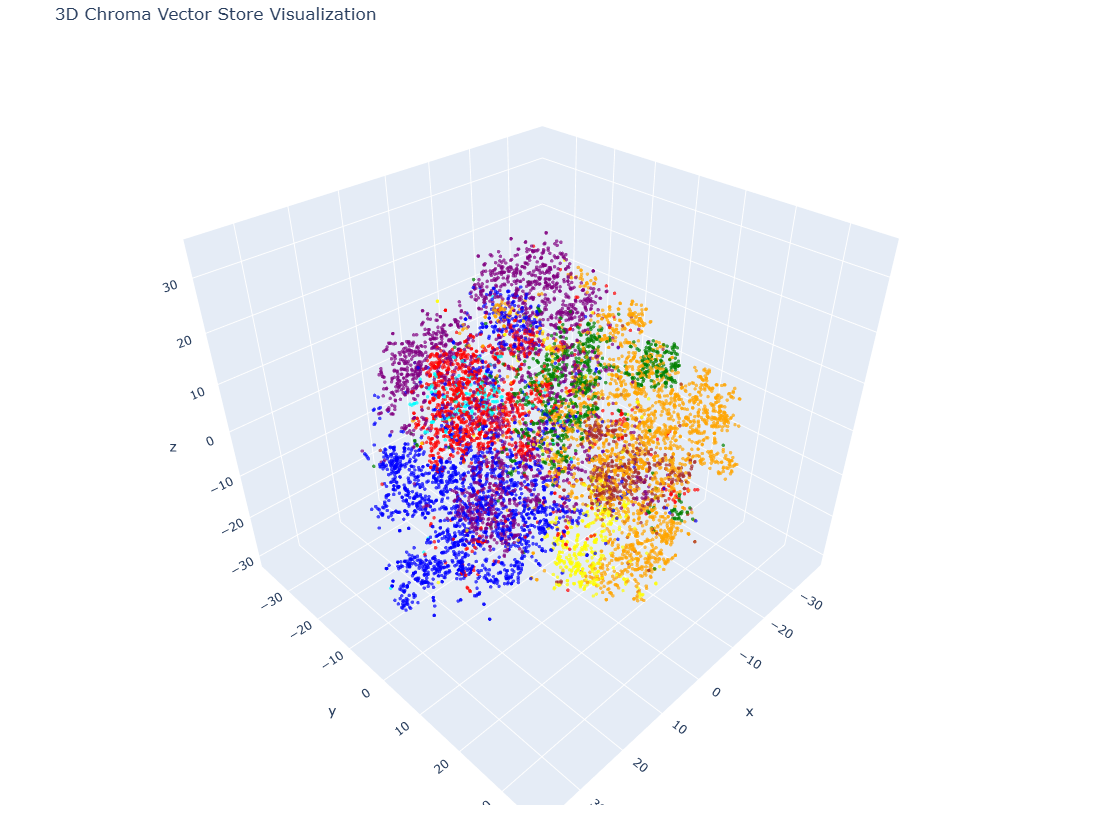

In [16]:
# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=2, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [14]:
test[0]

<Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal = $219.0>

In [15]:
def vector(item):
    return encoder.encode(item.summary)

In [16]:
def find_similars(item):
    vec = vector(item)
    results = collection.query(query_embeddings=vec.astype(float).tolist(), n_results=5)
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

In [17]:
find_similars(test[0])

(['Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  \nCategory: Music Equipment → Effects Pedals  \nBrand: Boss  \nDescription: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  \nDetails: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1\u202fMΩ input impedance.',
  'Title: Bit Commander V2 Monophonic Analog Guitar Synth Pedal  \nCategory: Guitar Pedals  \nBrand: Earthquaker Devices  \nDescription: A monophonic analog synth pedal that adds up to four octave-augmented square‑wave tones to any guitar signal.  \nDetails: Features true bypass, a simple push‑button interface for octave selection, and a 9V power input.',
  'Title: Old Blood Noise Headphone Amp Pedal  \nCategory: Audio Equipment  \nBrand: Old Blood Noise  \nDescription: A compact headphone amp pedal that lets you enjoy your pedalboard at full volume without disturbing others.  \nDetails: F

In [18]:
# We need to give some context to GPT-5.1 by selecting 5 products with similar descriptions

def make_context(similars, prices):
    message = "For context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

In [19]:
documents, prices = find_similars(test[0])
print(make_context(documents, prices))

For context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  
Category: Music Equipment → Effects Pedals  
Brand: Boss  
Description: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  
Details: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1 MΩ input impedance.
Price is $109.99

Potentially related product:
Title: Bit Commander V2 Monophonic Analog Guitar Synth Pedal  
Category: Guitar Pedals  
Brand: Earthquaker Devices  
Description: A monophonic analog synth pedal that adds up to four octave-augmented square‑wave tones to any guitar signal.  
Details: Features true bypass, a simple push‑button interface for octave selection, and a 9V power input.
Price is $199.00

Potentially related product:
Title: Old Blood Noise Headphone Amp Pedal

In [20]:
def messages_for(item, similars, prices):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}\n\n"
    message += make_context(similars, prices)
    return [{"role": "user", "content": message}]

In [21]:
documents, prices = find_similars(test[0])
print(messages_for(test[0], documents, prices)[0]['content'])

Estimate the price of this product. Respond with the price, no explanation

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

For context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  
Category: Music Equipment → Effects Pedals  
Brand: Boss  
Description: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  
Details: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adj

In [22]:
# The function for gemini-3-flash

def gemini_3_rag(item):
    documents, prices = find_similars(item)
    response = completion(model="gemini/gemini-3-flash-preview", messages=messages_for(item, documents, prices), reasoning_effort="none")
    return response.choices[0].message.content

In [23]:
# How much does our favorite distortion pedal cost?

test[0].price

219.0

In [24]:
# Let's do this!!

gemini_3_rag(test[0])

'$209.00'

  0%|▍                                                                                                  | 1/200 [00:01<05:06,  1.54s/it]

$10 $24 

  2%|█▍                                                                                                 | 3/200 [00:01<01:35,  2.06it/s]

$11 $15 $10 

  3%|██▉                                                                                                | 6/200 [00:02<01:13,  2.64it/s]

...

$0 $41 $0 

 98%|███████████████████████████████████████████████████████████████████████████████████████████████  | 196/200 [00:54<00:01,  3.96it/s]

$15 $11 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:56<00:00,  3.56it/s]

$32 $12 $11 

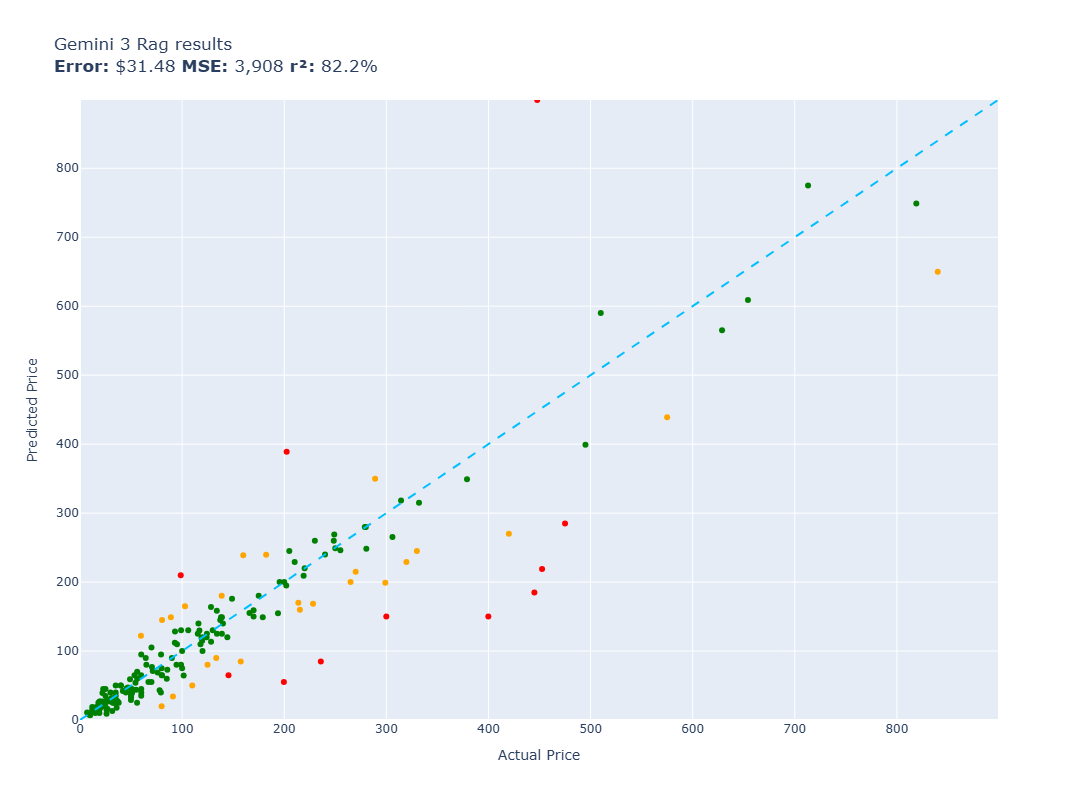

In [25]:
evaluate(gemini_3_rag, test)

In [ ]:
import modal
Pricer = modal.Cls.from_name("pricer-service", "Pricer")
pricer = Pricer()

In [ ]:
def specialist(item):
    return pricer.price.remote(item.summary)


In [ ]:
def get_price(reply):
    reply = reply.replace("$", "").replace(",", "")
    match = re.search(r"[-+]?\d*\.\d+|\d+", reply)
    return float(match.group()) if match else 0

In [26]:

from agents.deep_neural_network import DeepNeuralNetworkInference

runner = DeepNeuralNetworkInference()
runner.setup()
runner.load("deep_neural_network.pth")

def deep_neural_network(item):
    return runner.inference(item.summary)

In [28]:
def ensemble(item):
    price1 = get_price(gemini_3_rag(item))
    price2 = specialist(item)
    price3 = deep_neural_network(item)
    return price1 * 0.8 + price2 * 0.1 + price3 * 0.1


In [ ]:
evaluate(ensemble, test)

In [ ]:
root = logging.getLogger()
root.setLevel(logging.INFO)

In [ ]:
from agents.frontier_agent import FrontierAgent

agent = FrontierAgent(collection)
agent.price("Quadcast HyperX condenser mic, connects via usb-c to your computer for crystal clear audio")

In [ ]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")

In [ ]:
from agents.neural_network_agent import NeuralNetworkAgent
agent = NeuralNetworkAgent()


In [ ]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")

In [ ]:
from agents.ensemble_agent import EnsembleAgent
agent = EnsembleAgent(collection)

In [ ]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")